In [1]:
import numpy as np
import torch
import model_definition as m
import utils as u
from torch.utils.data import DataLoader, random_split

In [2]:
model_path = "/more_data/models/new_vit_052427/checkpoint_180_val_0.1454.pth"
batch_size = 64
data_dir = "/root/emit_data/*"
masking_ratio = 0.75
device = torch.device("cuda")

In [3]:
full_dataset = u.HyperspectralDataset(data_dir)
_, _, test_dataset = random_split(
    full_dataset, [0.8, 0.1, 0.1],
    generator=torch.Generator().manual_seed(0)
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
)

Dataset initialized with 6340 files.


In [4]:
model = m.SimpleHyperspectralMAEEncoder(masking_ratio=masking_ratio).to(device)
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()
print(f"Loaded model from {model_path}")

/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loaded model from /more_data/models/new_vit_052427/checkpoint_180_val_0.1454.pth


In [5]:
test_loss = 0.0
with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        with torch.autocast(device_type="cuda"):
            pred, mask, patches = model(batch)
            loss = model.weighted_holistic_loss(pred, mask, patches)
        test_loss += loss.item()

test_loss /= len(test_dataloader)
print(f"Test Loss (weighted_holistic): {test_loss:.4f}")

Test Loss (weighted_holistic): 0.1412


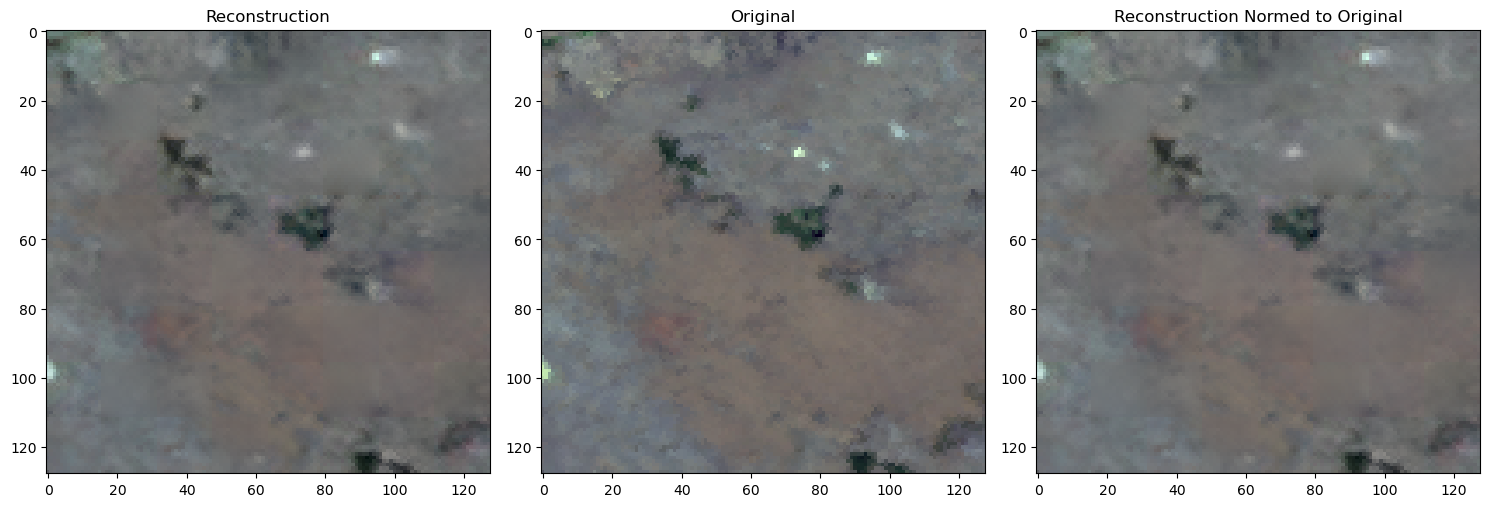

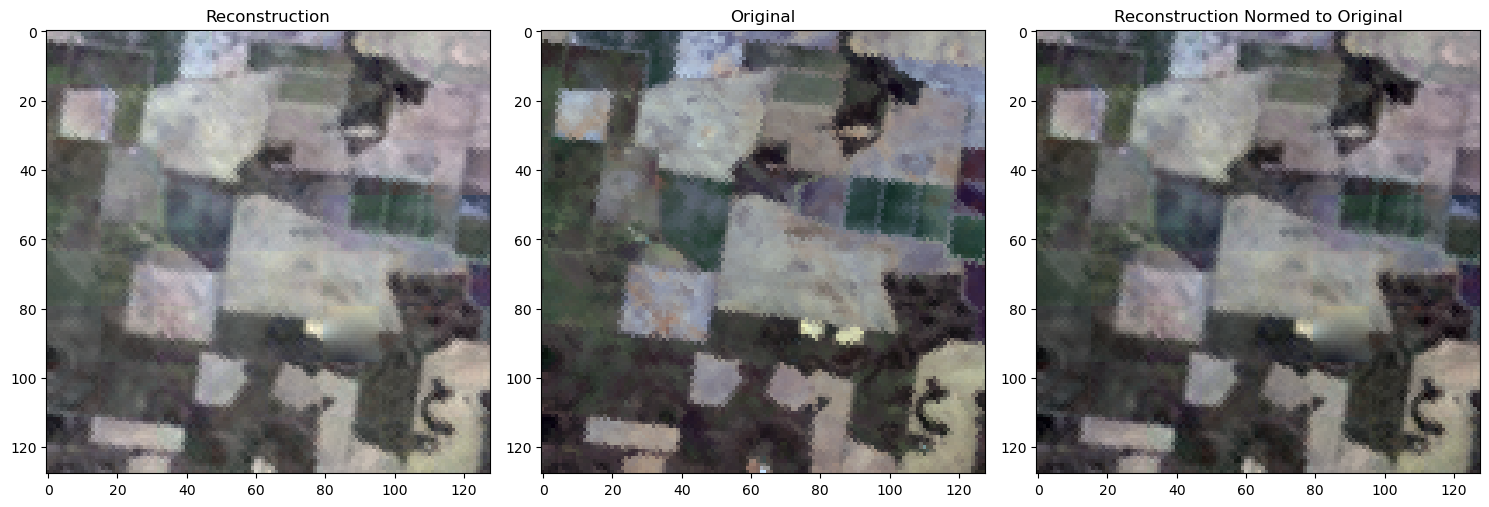

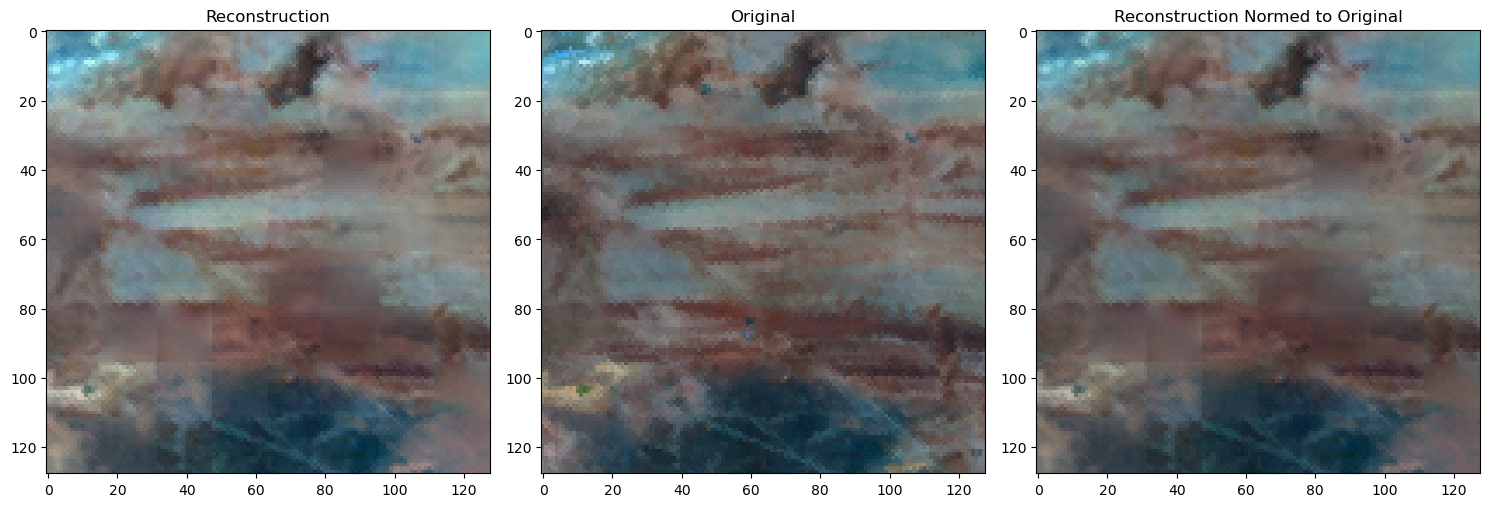

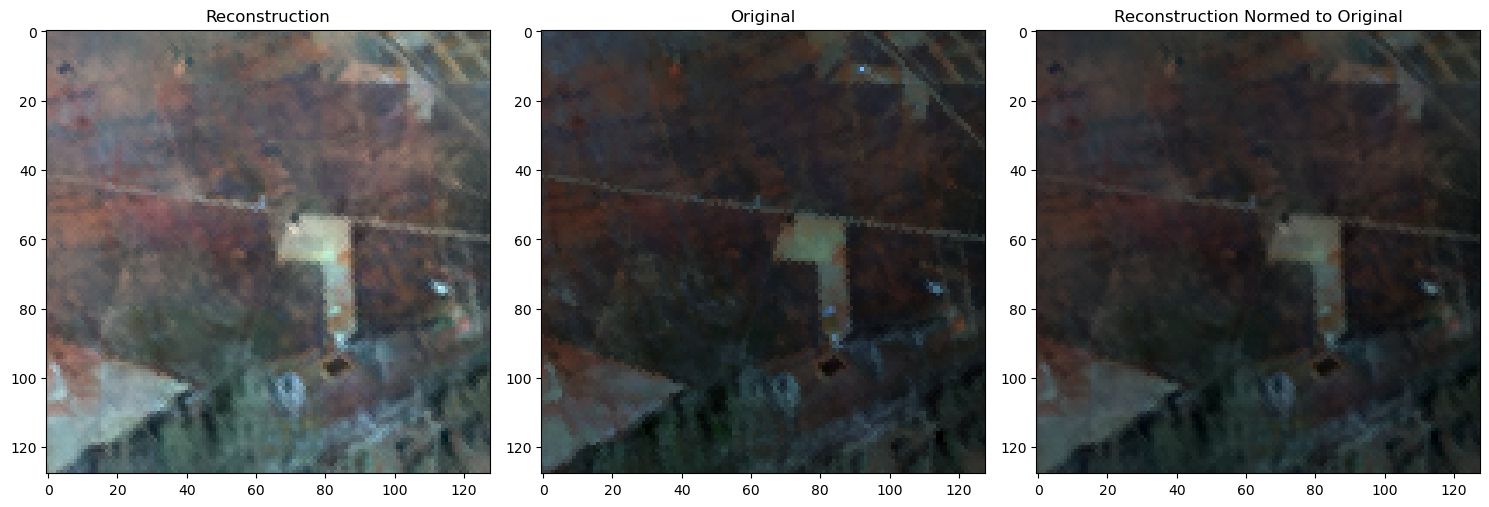

In [6]:
vis_batch = next(iter(test_dataloader))
num_samples = min(4, vis_batch.shape[0])

with torch.no_grad():
    for i in range(num_samples):
        single_chip = vis_batch[i].unsqueeze(0).to(device)
        pred_hwc = model.reconstruct(single_chip)

        pred_np = pred_hwc[0].cpu().numpy()
        orig_np = single_chip[0].cpu().numpy()
        u.visualize_reconstruction(pred_np, orig_np)

In [8]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_values = []
ssim_values = []

with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        pred_hwc = model.reconstruct(batch)

        pred_np = pred_hwc.cpu().numpy()
        orig_np = batch.cpu().numpy()

        for i in range(pred_np.shape[0]):
            pred_sample = pred_np[i]
            orig_sample = orig_np[i]

            data_range = orig_sample.max() - orig_sample.min()

            psnr_val = psnr(orig_sample, pred_sample, data_range=data_range)
            psnr_values.append(psnr_val)

            ssim_val = ssim(orig_sample, pred_sample, data_range=data_range, channel_axis=2)
            ssim_values.append(ssim_val)

print(f"Test PSNR: {np.mean(psnr_values):.2f} ± {np.std(psnr_values):.2f} dB")
print(f"Test SSIM: {np.mean(ssim_values):.4f} ± {np.std(ssim_values):.4f}")

Test PSNR: 34.95 ± 3.29 dB
Test SSIM: 0.8569 ± 0.0432
